## Scenario 1

In [1]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
df = pd.read_csv("Groceries_dataset.csv")

print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [4]:
# Convert dataset into list of transactions
transactions = df.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

print(transactions[:5])

[['soda', 'canned beer', 'sausage', 'sausage', 'whole milk', 'whole milk', 'pickled vegetables', 'misc. beverages', 'semi-finished bread', 'hygiene articles', 'yogurt', 'pastry', 'salty snack'], ['frankfurter', 'frankfurter', 'beef', 'sausage', 'whole milk', 'soda', 'curd', 'white bread', 'whole milk', 'soda', 'whipped/sour cream', 'rolls/buns'], ['tropical fruit', 'butter milk', 'butter', 'frozen vegetables', 'sugar', 'specialty chocolate', 'whole milk', 'other vegetables'], ['sausage', 'root vegetables', 'rolls/buns', 'detergent', 'frozen meals', 'rolls/buns', 'dental care', 'rolls/buns'], ['other vegetables', 'pip fruit', 'root vegetables', 'canned beer', 'rolls/buns', 'whole milk', 'other vegetables', 'hygiene articles', 'whole milk', 'whole milk', 'frozen fish', 'red/blush wine', 'chocolate', 'shopping bags', 'dish cleaner', 'packaged fruit/vegetables', 'tropical fruit', 'rolls/buns', 'cling film/bags', 'chocolate', 'pastry']]


In [5]:
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

print(df_encoded.head())

   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False   True    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

In [6]:
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

print(frequent_itemsets.head())

    support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)


In [7]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print(rules.head())

  antecedents         consequents  antecedent support  consequent support  \
0  (UHT-milk)  (other vegetables)            0.078502            0.376603   
1  (UHT-milk)        (rolls/buns)            0.078502            0.349666   
2  (UHT-milk)              (soda)            0.078502            0.313494   
3  (UHT-milk)        (whole milk)            0.078502            0.458184   
4      (beef)  (other vegetables)            0.119548            0.376603   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.038994    0.496732  1.318979               1.0  0.009430    1.238697   
1  0.031042    0.395425  1.130863               1.0  0.003592    1.075687   
2  0.027450    0.349673  1.115406               1.0  0.002840    1.055632   
3  0.040534    0.516340  1.126928               1.0  0.004565    1.120242   
4  0.050795    0.424893  1.128223               1.0  0.005773    1.083966   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.262440  0.09

In [8]:
# Filter high-quality rules
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]

print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                       antecedents   consequents   support  confidence  \
3                       (UHT-milk)  (whole milk)  0.040534    0.516340   
7                           (beef)  (whole milk)  0.064135    0.536481   
22                  (bottled beer)  (whole milk)  0.085428    0.537964   
28                 (bottled water)  (whole milk)  0.112365    0.525810   
33                   (brown bread)  (whole milk)  0.069779    0.513208   
..                             ...           ...       ...         ...   
857    (whole milk, sausage, soda)  (rolls/buns)  0.021036    0.525641   
858    (rolls/buns, soda, sausage)  (whole milk)  0.021036    0.585714   
861  (whole milk, sausage, yogurt)  (rolls/buns)  0.022832    0.508571   
862  (rolls/buns, yogurt, sausage)  (whole milk)  0.022832    0.640288   
866     (soda, rolls/buns, yogurt)  (whole milk)  0.024628    0.581818   

         lift  
3    1.126928  
7    1.170886  
22   1.174124  
28   1.147597  
33   1.120091  
..        ...  

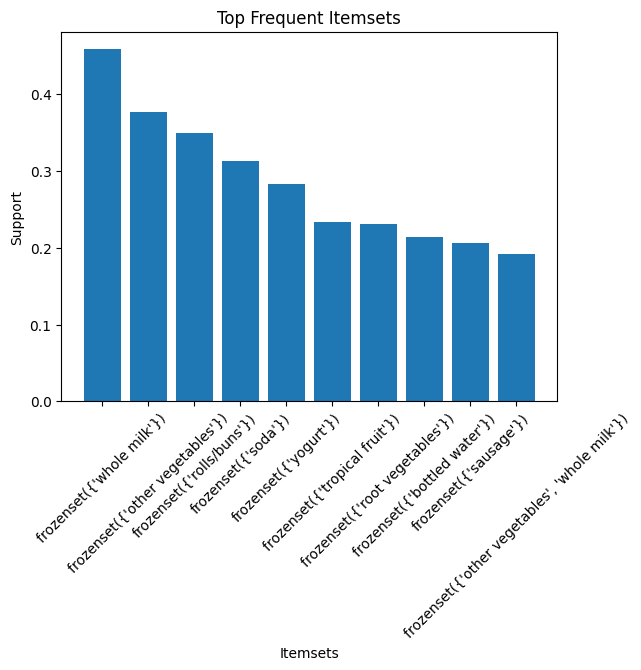

In [9]:
# Top 10 frequent itemsets
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure()
plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=45)

plt.title("Top Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.show()

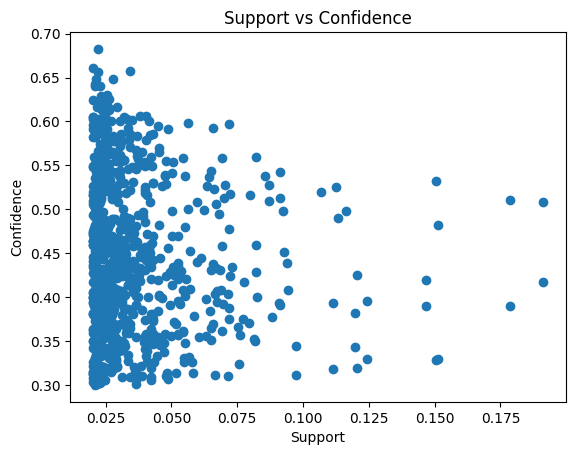

In [10]:
plt.figure()

plt.scatter(rules['support'], rules['confidence'])

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.show()

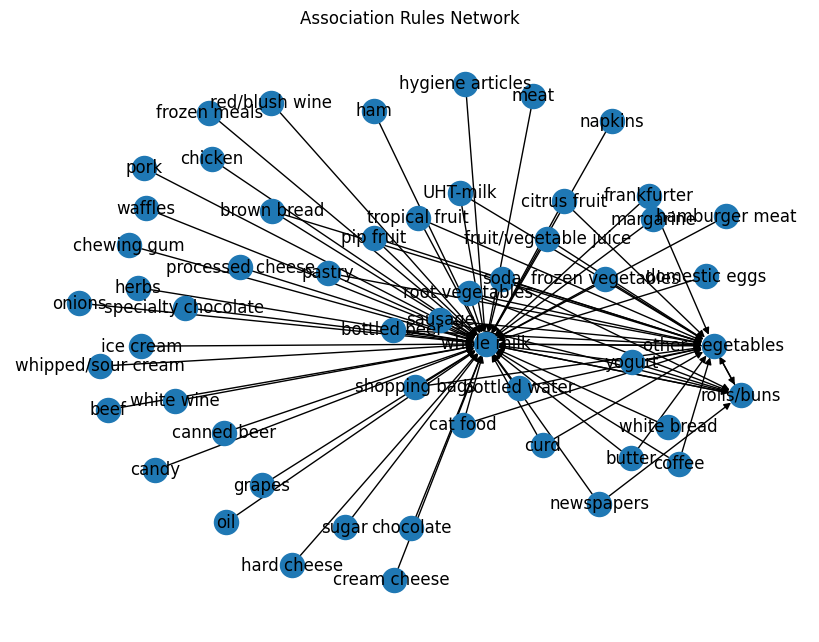

In [11]:
import networkx as nx

G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)

plt.title("Association Rules Network")
plt.show()

## Scenario 2


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [14]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [17]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]


In [18]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative Variance:")
print(cumulative_variance)

Cumulative Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


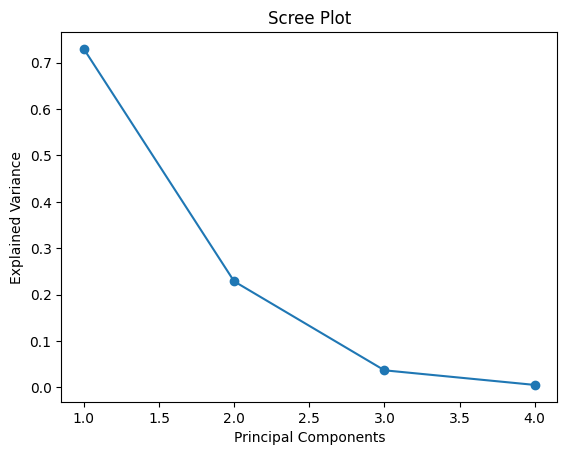

In [19]:
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')

plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")

plt.show()

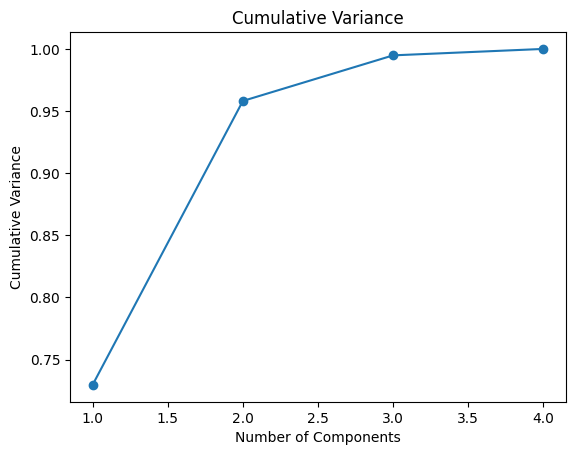

In [20]:
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')

plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.show()

In [21]:
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

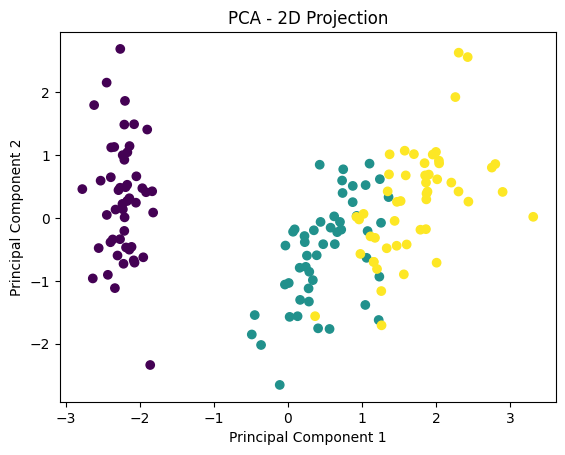

In [22]:
plt.figure()

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)

plt.title("PCA - 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

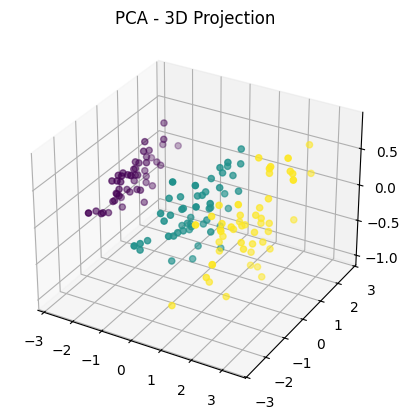

In [23]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
X_3d = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y)

ax.set_title("PCA - 3D Projection")

plt.show()